<a href="https://colab.research.google.com/github/FranktheBad/FluidFlowInterpolation/blob/main/Simple_Hybrid_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

In [ ]:
starboard_side=pd.read_csv('/content/day_9stbd')
#starboard_side['datetime'] = pd.to_datetime(starboard_side['time'],unit="s", utc=False)
port_side=pd.read_csv('/content/day_9port')
#port_side['datetime'] = pd.to_datetime(port_side['time'],unit="s", utc=False)
starboard_side=starboard_side.drop('time',axis=1)
port_side=port_side.drop('time',axis=1)

In [ ]:
starboard_side

,rpm,load,torque_nm,power_kw,bsfc,fuel_lph,datetime
0,470,44,278.782274,13.721612,229.415,3.703463,2025-06-16 11:02:49.093329906
1,508,44,278.575954,14.820042,229.415,3.999929,2025-06-16 11:02:49.220740080
2,532,48,308.141473,17.167375,225.935,4.563189,2025-06-16 11:02:49.338399887
3,464,49,311.350286,15.128970,225.140,4.007219,2025-06-16 11:02:49.472520113
4,502,49,309.672650,16.279785,225.140,4.312036,2025-06-16 11:02:49.587409973
...,...,...,...,...,...,...,...
277490,492,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:41.851520061
277491,438,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:41.989540100
277492,376,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:42.156630039
277493,288,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:42.370850086


In [ ]:
bsfc_df = pd.read_excel(
    "ENGINE_DATA_MARCEL-CARNE.xlsm",
    sheet_name="Full BSFC map",     # change if needed
    header=0            # RPM as index
)
rpm_grid = bsfc_df.iloc[4:, 1].dropna().to_numpy(dtype=float)
torque_grid = bsfc_df.iloc[3, 2:].dropna().to_numpy(dtype=float)
bsfc = bsfc_df.iloc[
    4:4+len(rpm_grid),      # rows for RPM
    2:2+len(torque_grid)   # columns for torque
].to_numpy(dtype=float)

bsfc_interp = RegularGridInterpolator(
    (rpm_grid, torque_grid),
    bsfc,
    bounds_error=False,
    fill_value=None
)

In [ ]:
def simple_hybrid_simulator(df):
    # Battery
  BATTERY_KWH = 350
  SOC_MIN = 0.2 * BATTERY_KWH
  SOC_MAX = 0.8 * BATTERY_KWH
  SOC_TARGET = 0.6 * BATTERY_KWH

  # Motor
  MOTOR_MAX_TORQUE = 1500      # Nm
  GEN_MAX_TORQUE = 1200        # Nm
  MOTOR_EFF = 0.95

  # Engine
  idle_torque_threshold = 10 # Nm,
  idle_rpm_min = 100    # Nm
  BSFC_THRESHOLD = df['bsfc'].min()*1.2        # g/kWh

  # Time step
  dt = np.mean(np.diff(df["datetime"])).astype("timedelta64[s]").astype(float)

  def engine_power_kw(rpm, torque_nm):
      return 2 * np.pi * rpm * torque_nm / 60_000


  def fuel_flow_gps(bsfc, power_kw):
      return (bsfc * power_kw) / 3600

  soc = SOC_TARGET

  fuel_gps_hybrid = []
  motor_power_kw = []
  soc_trace = []
  engine_on_trace = []

  for _, row in df.iterrows():

      rpm = row["rpm"]
      T_demand = row["torque_nm"]

      # -------------------------------
      # 1. ENGINE OFF / MOTOR ONLY (IDLE)
      # -------------------------------
      if (T_demand <= idle_torque_threshold) and (rpm >= idle_rpm_min) and (soc > SOC_MIN):
        engine_on = False
        T_engine = 0.0
        T_motor = min(T_demand, MOTOR_MAX_TORQUE)
        P_motor = engine_power_kw(rpm, T_motor)
        soc -= (P_motor / MOTOR_EFF) * dt / 3600  # dt in seconds, SOC in Ah or fraction
        fuel_gps = 0.0

      else:
          engine_on = True

          # -------------------------------
          # 2. ASSIST MODE (HIGH BSFC)
          # -------------------------------
          if (row["bsfc"] > BSFC_THRESHOLD) and (soc > SOC_MIN):
              T_motor = min(0.3 * T_demand, MOTOR_MAX_TORQUE)

          # -------------------------------
          # 3. CHARGE MODE (LOW SOC)
          # -------------------------------
          elif soc < SOC_TARGET:
              T_motor = -GEN_MAX_TORQUE

          # -------------------------------
          # 4. NORMAL ENGINE MODE
          # -------------------------------
          else:
              T_motor = 0.0

          # -------------------------------
          # 5. TORQUE BALANCE
          # -------------------------------
          T_engine = max(T_demand - T_motor, 0.0)

          # Clamp engine operating point
          rpm_q = np.clip(rpm, rpm_grid.min(), rpm_grid.max())
          T_engine = np.clip(T_engine, torque_grid.min(), torque_grid.max())

          # -------------------------------
          # 6. ENGINE FUEL CONSUMPTION
          # -------------------------------
          P_engine = engine_power_kw(rpm_q, T_engine)
          bsfc_new = bsfc_interp([[rpm_q, T_engine]])[0]
          fuel_gps = fuel_flow_gps(bsfc_new, P_engine)

          # -------------------------------
          # 7. MOTOR / BATTERY UPDATE
          # -------------------------------
          P_motor = engine_power_kw(rpm, T_motor)

          if P_motor >= 0:   # discharging
              soc -= (P_motor / MOTOR_EFF) * dt / 3600
          else:              # charging
              soc -= (P_motor * MOTOR_EFF) * dt / 3600

      # -------------------------------
      # 8. SOC LIMITS
      # -------------------------------
      soc = np.clip(soc, SOC_MIN, SOC_MAX)

      # -------------------------------
      # 9. LOG RESULTS
      # -------------------------------
      fuel_gps_hybrid.append(fuel_gps)
      motor_power_kw.append(P_motor)
      soc_trace.append(soc)
      engine_on_trace.append(engine_on)

  df["fuel_gps_hybrid"] = fuel_gps_hybrid
  df["motor_power_kw"] = motor_power_kw
  df["soc_kwh"] = soc_trace
  df["engine_on"] = engine_on_trace

  return df



In [ ]:
def simple_hybrid_simulator(df):
    # =========================
    # BATTERY PARAMETERS
    # =========================
    BATTERY_KWH = 350
    SOC_MIN = 0.3 * BATTERY_KWH
    SOC_MAX = 0.8 * BATTERY_KWH
    SOC_REF = 0.8 * BATTERY_KWH  # soft reference

    BATTERY_MAX_DISCHARGE_KW = 400
    BATTERY_MAX_CHARGE_KW = 300
    MOTOR_EFF = 0.95
    GEN_EFF = 0.95

    # =========================
    # ENGINE / MOTOR
    # =========================
    MOTOR_MAX_TORQUE = 1500
    GEN_MAX_TORQUE = 600
    idle_torque_threshold = 10
    idle_rpm_min = 100
    BSFC_THRESHOLD = 260

    # Weak SOC bias (small, causes oscillation)
    K_SOC = 2.5  # kW per kWh error

    # =========================
    # TIME STEP
    # =========================
    dt = np.mean(np.diff(df["datetime"]).astype("timedelta64[s]").astype(float))

    # =========================
    # INITIAL STATE
    # =========================
    soc = SOC_REF

    fuel_gps = []
    motor_power_kw = []
    soc_trace = []
    engine_on_trace = []
    mode_trace = []

    # =========================
    # MAIN LOOP
    # =========================
    for _, row in df.iterrows():

        rpm = row["rpm"]
        T_demand = row["torque_nm"]
        bsfc = row["bsfc"]

        engine_on = True
        mode = 1
        T_motor = 0.0
        T_engine = 0.0

        # -------------------------------
        # 1. FULL ELECTRIC (motor only)
        # -------------------------------
        if T_demand <= idle_torque_threshold and rpm >= idle_rpm_min and soc > SOC_MIN:
            engine_on = False
            mode = 3
            T_motor = min(T_demand, MOTOR_MAX_TORQUE)
            P_motor = 2 * np.pi * rpm * T_motor / 60_000
            soc -= (P_motor / MOTOR_EFF) * dt / 3600
            fuel = 0.0

        else:
            # -------------------------------
            # 2. ASSIST MODE (engine + motor)
            # -------------------------------
            if bsfc > BSFC_THRESHOLD and soc > SOC_MIN:
                mode = 2
                T_motor = min(0.3 * T_demand, MOTOR_MAX_TORQUE)
            else:
                T_motor = 0.0
                mode = 1

            # -------------------------------
            # 3. SOC BIAS (VERY WEAK)
            # -------------------------------
            soc_error = soc - SOC_REF
            # convert bias power to torque
            P_soc_bias = K_SOC * soc_error
            if rpm > 1:
                T_soc_bias = (P_soc_bias * 60_000) / (2 * np.pi * rpm)
            else:
                T_soc_bias = 0.0

            T_motor -= T_soc_bias
            T_motor = np.clip(T_motor, -GEN_MAX_TORQUE, MOTOR_MAX_TORQUE)

            # -------------------------------
            # 4. TORQUE BALANCE
            # -------------------------------
            T_engine = max(T_demand - T_motor, 0.0)
            rpm_q = np.clip(rpm, rpm_grid.min(), rpm_grid.max())
            T_engine = np.clip(T_engine, torque_grid.min(), torque_grid.max())

            # -------------------------------
            # 5. ENGINE POWER & FUEL
            # -------------------------------
            P_engine = 2 * np.pi * rpm_q * T_engine / 60_000
            bsfc_eff = bsfc_interp([[rpm_q, T_engine]])[0]
            fuel = fuel_flow_gps(bsfc_eff, P_engine)

            # -------------------------------
            # 6. MOTOR POWER & SOC UPDATE
            # -------------------------------
            P_motor = 2 * np.pi * rpm * T_motor / 60_000

            if P_motor >= 0:
                soc -= (P_motor / MOTOR_EFF) * dt / 3600
            else:
                soc -= (P_motor * GEN_EFF) * dt / 3600

        # -------------------------------
        # 7. SOC LIMITS
        # -------------------------------
        soc = np.clip(soc, SOC_MIN, SOC_MAX)

        # -------------------------------
        # 8. LOGGING
        # -------------------------------
        fuel_gps.append(fuel)
        motor_power_kw.append(P_motor)
        soc_trace.append(soc)
        engine_on_trace.append(engine_on)
        mode_trace.append(mode)

    # -------------------------------
    # STORE RESULTS
    # -------------------------------
    df["fuel_gps_hybrid"] = fuel_gps
    df["motor_power_kw"] = motor_power_kw
    df["soc_kwh"] = soc_trace
    df["engine_on"] = engine_on_trace
    df["hybrid_mode"] = mode_trace

    return df


# Helper for fuel flow (same as before)
def fuel_flow_gps(bsfc, power_kw):
    return (bsfc * max(power_kw, 0)) / 3600


In [ ]:
port_side["datetime"] = pd.to_datetime(port_side["datetime"])
starboard_side["datetime"] = pd.to_datetime(starboard_side["datetime"])


In [ ]:
port_side= simple_hybrid_simulator(port_side)

In [ ]:
modecount_port=port_side['hybrid_mode'].value_counts()
modecount_port

,count
hybrid_mode,
2,133445
1,130256
3,685


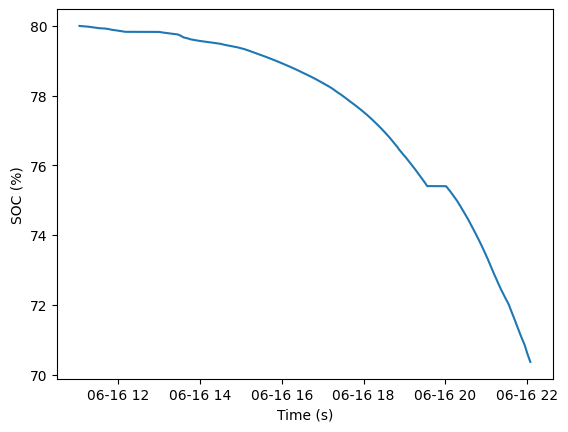

In [ ]:
plt.plot(port_side["datetime"], port_side["soc_kwh"] / 350 * 100)
plt.ylabel("SOC (%)")
plt.xlabel("Time (s)")
plt.show()

In [ ]:
def fuel_flow_gps(bsfc, power_kw):
    # returns fuel in grams per second
    return (bsfc * power_kw) / 3600

In [ ]:
 def fuel_bh(df):
    df["delta_t"] = df["datetime"].diff().dt.total_seconds()
    df["delta_t"].fillna(0, inplace=True)
    df['fuel_base(g)']=df['fuel_baseline_gps']*df['delta_t']
    df['fuel_hybrid(g)']=df['fuel_gps_hybrid']*df['delta_t']

    fuel_base=df['fuel_base(g)'].sum()
    fuel_hybrid=df['fuel_hybrid(g)'].sum()
    fuel_reduction_pct = 100 * (fuel_base - fuel_hybrid) / fuel_base
    return (fuel_base,fuel_hybrid,fuel_reduction_pct)


In [ ]:
port_side['P_engine_kw'] = 2 * np.pi * port_side['rpm'] * port_side['torque_nm'] / 60_000
port_side['fuel_baseline_gps'] = fuel_flow_gps(port_side['bsfc'], port_side['P_engine_kw'])
port_side['fuel_gps_hybrid'] = port_side['fuel_gps_hybrid'].fillna(0)
port_side['fuel_baseline_gps'] = port_side['fuel_baseline_gps'].fillna(0)


In [ ]:
fuel_bh(port_side)

/tmp/ipython-input-1211207565.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["delta_t"].fillna(0, inplace=True)


(np.float64(135411.35312022394),
 np.float64(66306.38820669103),
 np.float64(51.03336117775782))

In [ ]:
port_side

,rpm,load,torque_nm,power_kw,bsfc,fuel_lph,datetime,fuel_gps_hybrid,motor_power_kw,soc_kwh,engine_on,hybrid_mode,P_engine_kw,fuel_baseline_gps,delta_t,fuel_base(g),fuel_hybrid(g)
0,456,43,274.598757,13.113104,230.360,3.553806,2025-06-16 11:02:42.705070019,1.735735,0.0,280.000000,True,1,13.112697,0.839067,0.00000,0.000000,0.000000
1,522,45,286.861310,15.681391,228.500,4.215527,2025-06-16 11:02:42.834969997,1.826139,0.0,280.000000,True,1,15.680904,0.995302,0.12990,0.129290,0.237215
2,602,48,337.132157,21.253907,225.935,5.649414,2025-06-16 11:02:42.983099937,0.000000,0.0,280.000000,True,1,21.253247,1.333848,0.14813,0.197583,0.000000
3,697,50,423.615695,30.920530,224.375,8.162110,2025-06-16 11:02:43.115080118,0.000000,0.0,280.000000,True,1,30.919569,1.927105,0.13198,0.254340,0.000000
4,863,50,589.702288,53.294908,224.375,14.068288,2025-06-16 11:02:43.264930010,0.000000,0.0,280.000000,True,1,53.293253,3.321576,0.14985,0.497738,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264381,474,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:45.180190086,0.000000,0.0,246.265986,False,3,0.000000,0.000000,0.13105,0.000000,0.000000
264382,412,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:45.331160069,0.000000,0.0,246.265986,False,3,0.000000,0.000000,0.15097,0.000000,0.000000
264383,324,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:45.513250113,0.000000,0.0,246.265986,False,3,0.000000,0.000000,0.18209,0.000000,0.000000
264384,277,0,0.000000,0.000000,0.000,0.000000,2025-06-16 22:04:45.644459963,0.000000,0.0,246.265986,False,3,0.000000,0.000000,0.13121,0.000000,0.000000


In [ ]:
def plot_cumsum(df):
  df['cumulative_hybrid'] = df['fuel_hybrid(g)'].cumsum()
  df['cumulative_baseline'] = df['fuel_base(g)'].cumsum()

  # Plot
  plt.figure(figsize=(10,6))
  plt.plot(df['datetime'], df['cumulative_hybrid'], label='Hybrid Cumulative Fuel')
  plt.plot(df['datetime'], df['cumulative_baseline'], label='Baseline Cumulative Fuel')
  plt.xlabel('Time')
  plt.ylabel('Cumulative Fuel Consumption')
  plt.title('Cumulative Fuel Consumption: Hybrid vs Baseline')
  plt.legend()
  plt.grid(True)
  return plt.show()

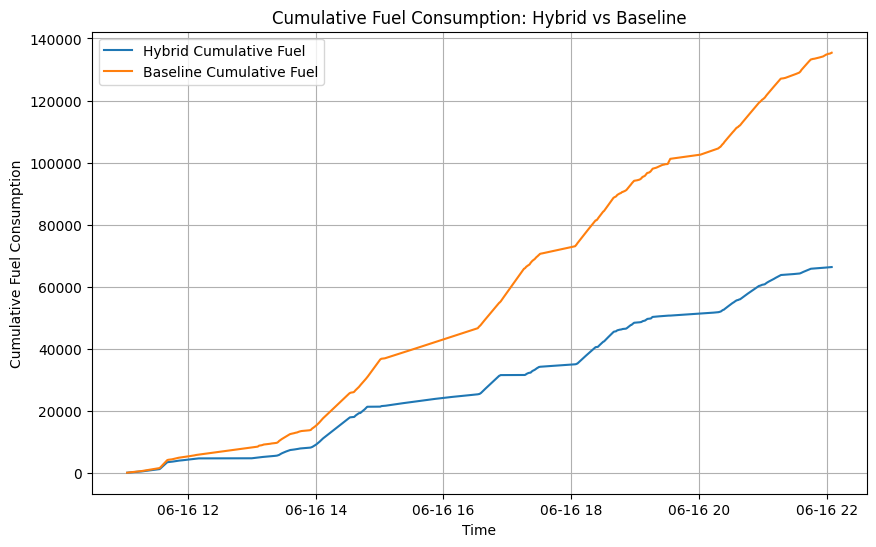

In [ ]:
plot_cumsum(port_side)

In [ ]:
starboard_side= simple_hybrid_simulator(starboard_side)
starboard_side['P_engine_kw'] = 2 * np.pi * starboard_side['rpm'] * starboard_side['torque_nm'] / 60_000
starboard_side['fuel_baseline_gps'] = fuel_flow_gps(starboard_side['bsfc'], starboard_side['P_engine_kw'])
starboard_side['fuel_gps_hybrid'] = starboard_side['fuel_gps_hybrid'].fillna(0)
starboard_side['fuel_baseline_gps'] = starboard_side['fuel_baseline_gps'].fillna(0)
fuel_bh(starboard_side)

/tmp/ipython-input-1211207565.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["delta_t"].fillna(0, inplace=True)


(np.float64(140232.18982430047),
 np.float64(54573.50563026442),
 np.float64(61.08346757000616))

In [ ]:
countsss2=starboard_side['hybrid_mode'].value_counts()
countsss2

,count
hybrid_mode,
1,148848
2,125833
3,2814


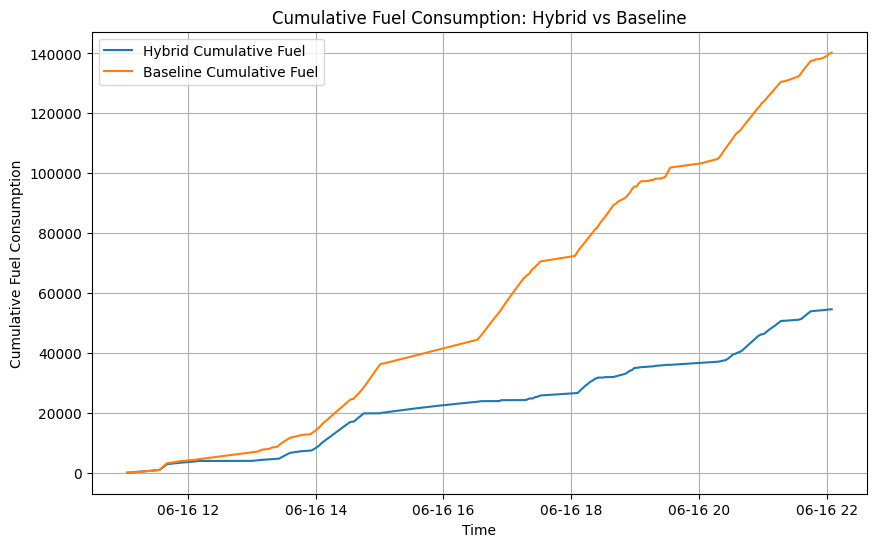

In [ ]:
plot_cumsum(starboard_side)

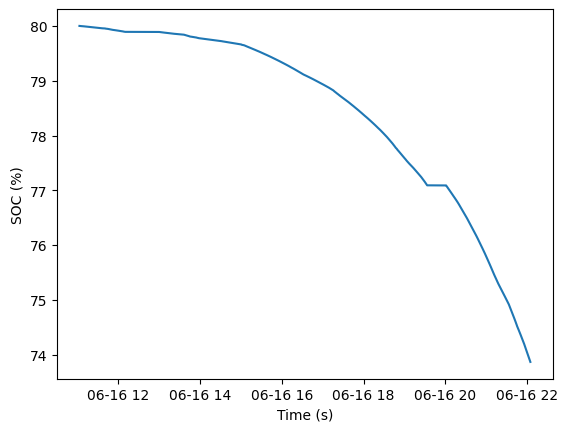

In [ ]:
plt.plot(starboard_side["datetime"], starboard_side["soc_kwh"] / 350 * 100)
plt.ylabel("SOC (%)")
plt.xlabel("Time (s)")
plt.show()

In [ ]:
def plot_mode(df):
  mode_labels = {1: 'Engine Only', 2: 'Engine-Battery', 3: 'Electric'}
  mode_colors = {1: 'red', 2: 'orange', 3: 'green'}
  plt.figure(figsize=(15,4))
  plt.step(df['datetime'], df['hybrid_mode'], where='post', linewidth=2, color='black')  # step plot
  plt.scatter(df['datetime'], df['hybrid_mode'], c=df['hybrid_mode'].map(mode_colors), s=100)  # colored markers

  # Customize y-axis with labels
  plt.yticks([1,2,3], [mode_labels[i] for i in [1,2,3]])
  plt.xlabel('Time')
  plt.ylabel('Vessel Mode')
  plt.title('Vessel Operating Mode Over Time')
  plt.grid(axis='y')
  return plt.show()

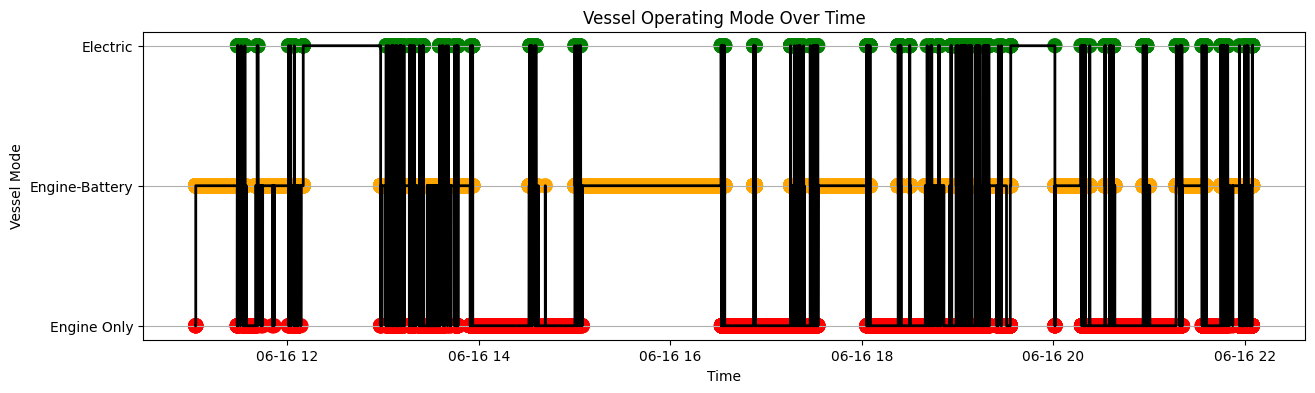

In [ ]:
plot_mode(port_side)

In [ ]:
def plot_mode_time_interval(df, start_time, end_time):
    mode_labels = {1: 'Engine Only', 2: 'Engine-Battery', 3: 'Electric'}
    mode_colors = {1: 'red', 2: 'orange', 3: 'green'}

    # Filter dataframe by time interval
    df_interval = df[
        (df['datetime'] >= start_time) &
        (df['datetime'] <= end_time)
    ]

    plt.figure(figsize=(15, 4))
    plt.step(
        df_interval['datetime'],
        df_interval['hybrid_mode'],
        where='post',
        linewidth=2,
        color='black'
    )
    plt.scatter(
        df_interval['datetime'],
        df_interval['hybrid_mode'],
        c=df_interval['hybrid_mode'].map(mode_colors),
        s=100
    )

    # Customize y-axis with labels
    plt.yticks([1, 2, 3], [mode_labels[i] for i in [1, 2, 3]])
    plt.xlabel('Time')
    plt.ylabel('Vessel Mode')
    plt.title('Vessel Operating Mode Over Selected Time Interval')
    plt.grid(axis='y')

    plt.show()



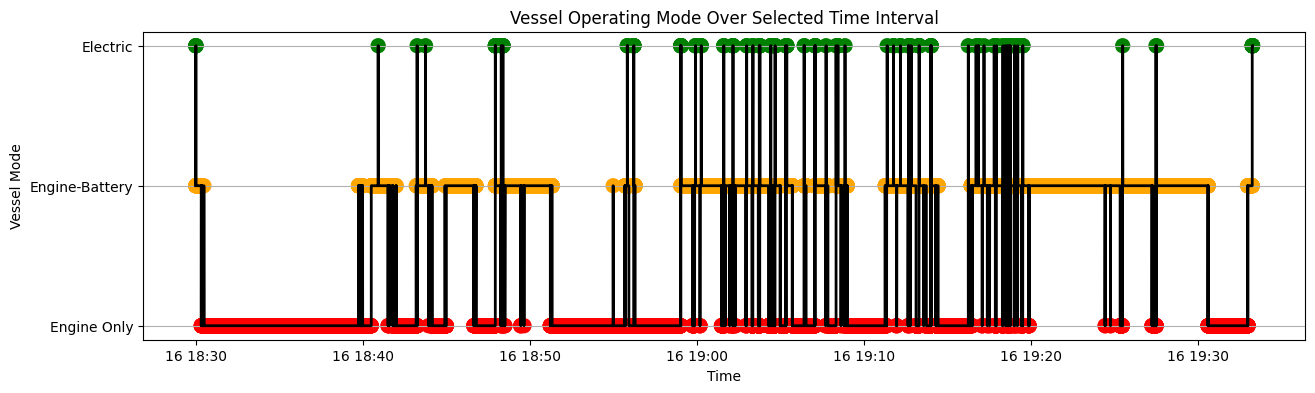

In [ ]:
plot_mode_time_interval(port_side,'2025-06-16 18:30:00','2025-06-16 20:00:00')

In [ ]:
def plot_mode2(df):
  # Map modes to colors and labels
  mode_labels = {1: 'Engine Only', 2: 'Engine-Battery', 3: 'Electric'}
  mode_colors = {1: 'red', 2: 'orange', 3: 'green'}

  # Plot each segment as a horizontal bar
  plt.figure(figsize=(12, 2))
  for i in range(len(df)-1):
      start = df['datetime'].iloc[i]
      end = df['datetime'].iloc[i+1]
      mode = df['hybrid_mode'].iloc[i]
      plt.barh(0, (end - start).total_seconds()/60, left=(start - df['datetime'].iloc[0]).total_seconds()/60,
              height=0.5, color=mode_colors[mode], edgecolor='k')

  # Last mode segment (extend arbitrarily or to next known datetime)
  last_start = df['datetime'].iloc[-1]
  last_mode = df['hybrid_mode'].iloc[-1]
  plt.barh(0, 5, left=(last_start - df['datetime'].iloc[0]).total_seconds()/60,  # e.g., extend 5 min
          height=0.5, color=mode_colors[last_mode], edgecolor='k')

  # Customize
  plt.yticks([])
  plt.xlabel('Time (minutes)')
  plt.title('Vessel Operating Mode Timeline')
  # Add legend
  for mode, color in mode_colors.items():
      plt.bar(0, 0, color=color, label=mode_labels[mode])
  plt.legend(loc='upper right')
  plt.grid(axis='x')

  # Format x-axis with actual datetime labels if desired
  plt.xticks(
      ticks=[(t - df['datetime'].iloc[0]).total_seconds()/60 for t in df['datetime']],
      labels=[t.strftime('%H:%M') for t in df['datetime']]
  )

  return plt.show()

In [ ]:
def plotmode2(df):
  # Map modes to colors
  mode_colors = {1: 'red', 2: 'orange', 3: 'green'}

  # Merge consecutive identical modes to reduce number of segments
  df['change'] = df['hybrid_mode'].ne(df['hybrid_mode'].shift()).cumsum()
  segments = df.groupby('change').agg(
      start=('datetime', 'first'),
      end=('datetime', 'last'),
      mode=('hybrid_mode', 'first')
  ).reset_index(drop=True)

  # Convert times to minutes relative to start
  start_time = df['datetime'].iloc[0]
  segments['start_min'] = (segments['start'] - start_time).dt.total_seconds()/60
  segments['duration_min'] = (segments['end'] - segments['start']).dt.total_seconds()/60 + 1  # add 1 to include last minute

  # Prepare bars for broken_barh: list of (start, duration)
  bars = [(row['start_min'], row['duration_min']) for idx, row in segments.iterrows()]
  colors = [mode_colors[row['mode']] for idx, row in segments.iterrows()]

  # Plot efficiently using broken_barh
  plt.figure(figsize=(15,2))
  plt.broken_barh(bars, (0, 0.5), facecolors=colors, edgecolors='k')

  # Customize
  plt.yticks([])
  plt.xlabel('Time (minutes)')
  plt.title('Vessel Operating Mode Timeline')

  # Legend
  mode_labels = {1: 'Engine Only', 2: 'Engine-Battery', 3: 'Electric'}
  for mode, color in mode_colors.items():
      plt.bar(0, 0, color=color, label=mode_labels[mode])
  plt.legend(loc='upper right')

  return plt.show()


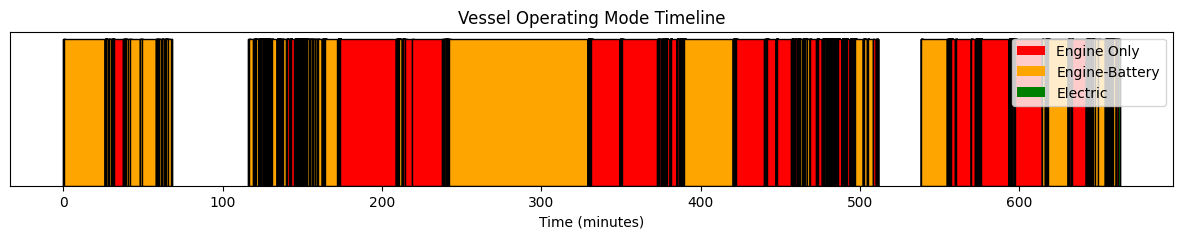

In [ ]:
plotmode2(port_side)

In [ ]:
def minplot(df):
  t0 = df['datetime'].iloc[0]

  # Keep only first 1800 seconds
  MAX_TIME = 1800
  df = df[df['datetime'] <= t0 + pd.Timedelta(seconds=MAX_TIME)]

  # Merge consecutive identical hybrid modes (critical for speed)
  df['change'] = df['hybrid_mode'].ne(df['hybrid_mode'].shift()).cumsum()
  segments = df.groupby('change').agg(
      start=('datetime', 'first'),
      end=('datetime', 'last'),
      hybrid_mode=('hybrid_mode', 'first')
  ).reset_index(drop=True)

  # Convert to relative seconds for plotting
  segments['start_sec'] = (segments['start'] - t0).dt.total_seconds()
  segments['duration_sec'] = (segments['end'] - segments['start']).dt.total_seconds()

  # Trim segments that cross the 1800 s boundary
  segments['duration_sec'] = segments.apply(
      lambda r: min(r['duration_sec'], MAX_TIME - r['start_sec']),
      axis=1
  )

  # Prepare bars
  mode_colors = {1: 'red', 2: 'orange', 3: 'green'}
  bars = list(zip(segments['start_sec'], segments['duration_sec']))
  colors = [mode_colors[m] for m in segments['hybrid_mode']]

  # Plot (efficient for large datasets)
  plt.figure(figsize=(15, 2))
  plt.broken_barh(bars, (0, 0.5), facecolors=colors)

  plt.yticks([])
  plt.xlabel('Time (seconds)')
  plt.title('Vessel Hybrid Operating Mode (First 1800 seconds)')
  plt.grid(axis='x')

  # Legend
  mode_labels = {1: 'Engine Only', 2: 'Engine–Battery', 3: 'Electric'}
  for m, c in mode_colors.items():
      plt.bar(0, 0, color=c, label=mode_labels[m])
  plt.legend(loc='upper right')

  return plt.show()

/tmp/ipython-input-2103421316.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['change'] = df['hybrid_mode'].ne(df['hybrid_mode'].shift()).cumsum()


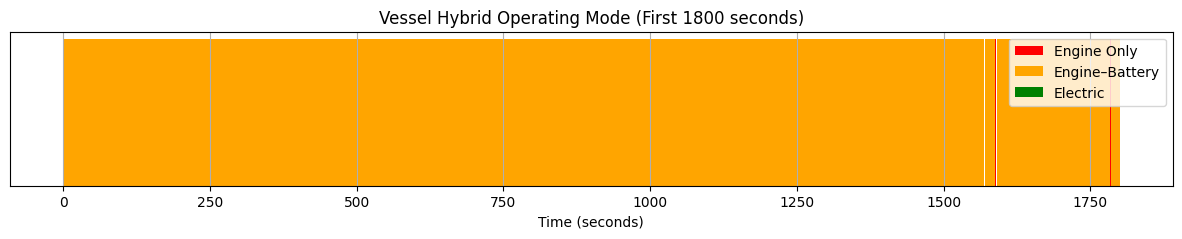

In [ ]:
minplot(port_side)